# Сравнение двух версий обучения (один проект AIP)

Сравниваются **две версии пайплайна** на одних данных. **Текущая** — `SimpleCNNClassifier` + `UNetNoPadding` (обучение `src/training/classification.py` и `segmentation.py` в AIP). **v1** — те же имена `.pt` в **`artifacts/v1/`**, но веса в формате **`SmallResNet` + `SimpleUNet`** как в проекте `Artificial-intelligence-project` (`main.py`); классы перенесены в `src.models.legacy_aip_v1`.

- **Текущая:** **`AIP/artifacts/`** — `classification_{ax|sa|co}_model.pt`, `segmentation_{ax|sa|co}_model.pt`.
- **v1:** **`AIP/artifacts/v1/`** — те же имена файлов.

**Данные:** **`AIP_ROOT/data/segmentation_task/`** — в первой ячейке `DATA_ROOT`/`DATA_SEG` от `AIP_ROOT` (как в `src.config`; в ноутбуке так обходят устаревший кэш `import`).  
**Отображение:** как в `test.ipynb`: исходный снимок и GT-маска **без масштабирования** (нативное разрешение файла); карты сегментации — каждая в размере выхода своей модели (`image_size` из чекпоинта), без приведения к общей решётке.

Ноутбук **не импортирует** чужие `main.py` и **не создаёт** каталог `logs` при выполнении — только инференс.

Запуск: рабочая папка **корень ВКР** (рядом с каталогом `AIP`) или **сам каталог AIP** — пути подстроятся автоматически.

In [19]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image

WK = Path(".").resolve()
# WK = Path(r"D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР")

if (WK / "src" / "config.py").is_file():
    AIP_ROOT = WK
elif (WK.parent / "src" / "config.py").is_file():
    AIP_ROOT = WK.parent
else:
    AIP_ROOT = WK / "AIP"

sys.path.insert(0, str(AIP_ROOT))
from src.config import CLASSES, CLS_NORM, SEG_NORM
from src.models.classification import SimpleCNNClassifier
from src.models.legacy_aip_v1 import SimpleUNet, SmallResNet
from src.models.segmentation import UNetNoPadding
from src.utils.checkpoint import load_checkpoint

# Как src.config._PROJECT_ROOT: пути от AIP_ROOT (без импорта DATA_ROOT/OUTPUT_DIR — кэш Jupyter).
DATA_ROOT = AIP_ROOT / "data"
DATA_SEG = DATA_ROOT / "segmentation_task"
ARTIFACTS_CURRENT = AIP_ROOT / "artifacts"
ARTIFACTS_V1 = AIP_ROOT / "artifacts" / "v1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_cur_cls: dict[str, tuple] = {}
_cur_seg: dict[str, tuple] = {}
_v1_cls: dict[str, tuple] = {}
_v1_seg: dict[str, tuple] = {}


def _parse_true_class_from_filename(name: str) -> str:
    parts = Path(name).stem.split("_")
    code = parts[3] if len(parts) > 3 else ""
    return {"me": "meningioma", "gl": "glioma", "pi": "pituitary", "no": "no_tumor"}.get(code, "?")


def _load_current_classification(plane: str):
    if plane in _cur_cls:
        return _cur_cls[plane]
    path = ARTIFACTS_CURRENT / f"classification_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    classes_ckpt = ckpt.get("classes", CLASSES)
    n_cls = len(classes_ckpt)
    norm = ckpt.get("norm_type", CLS_NORM)
    model = SimpleCNNClassifier(num_classes=n_cls, norm_type=norm).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    _cur_cls[plane] = (model, ckpt)
    return model, ckpt


def _load_current_segmentation(plane: str):
    if plane in _cur_seg:
        return _cur_seg[plane]
    path = ARTIFACTS_CURRENT / f"segmentation_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    norm = ckpt.get("norm_type", SEG_NORM)
    model = UNetNoPadding(in_ch=1, base=32, out_ch=1, norm_type=norm).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    _cur_seg[plane] = (model, ckpt)
    return model, ckpt


def _load_v1_classification(plane: str):
    if plane in _v1_cls:
        return _v1_cls[plane]
    path = ARTIFACTS_V1 / f"classification_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    classes_ckpt = ckpt.get("classes", CLASSES)
    n_cls = len(classes_ckpt)
    model = SmallResNet(num_classes=n_cls).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    _v1_cls[plane] = (model, ckpt)
    return model, ckpt


def _load_v1_segmentation(plane: str):
    if plane in _v1_seg:
        return _v1_seg[plane]
    path = ARTIFACTS_V1 / f"segmentation_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    model = SimpleUNet(in_ch=1, base=32, out_ch=1).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    _v1_seg[plane] = (model, ckpt)
    return model, ckpt


def show_prediction_compare(image_path: str | Path, plane: str) -> None:
    """Инференс текущих весов (artifacts/) и v1 (artifacts/v1/); визуализация как в test.ipynb (без общей решётки)."""
    plane = plane.lower().strip()
    if plane not in {"ax", "sa", "co"}:
        raise ValueError("plane должен быть ax, sa или co")

    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    true_class = _parse_true_class_from_filename(image_path.name)
    mask_path = image_path.parent.parent / "masks" / f"{image_path.stem}.png"
    if not mask_path.is_file():
        raise FileNotFoundError(f"Нет маски: {mask_path}")

    mask_img = Image.open(mask_path)
    display_img = Image.open(image_path)
    pil = display_img.convert("L")

    cur_cls_m, cur_cls_ck = _load_current_classification(plane)
    cur_seg_m, cur_seg_ck = _load_current_segmentation(plane)
    v1_cls_m, v1_cls_ck = _load_v1_classification(plane)
    v1_seg_m, v1_seg_ck = _load_v1_segmentation(plane)

    def _cls_tf(ckpt):
        c_mean, c_std = ckpt["mean"], ckpt["std"]
        c_size = int(ckpt["image_size"])
        return (
            T.Compose(
                [
                    T.Resize((c_size, c_size)),
                    T.ToTensor(),
                    T.Normalize(mean=[c_mean], std=[c_std]),
                ]
            ),
            c_size,
        )

    def _seg_tf(ckpt):
        s_mean, s_std = ckpt["mean"], ckpt["std"]
        s_size = int(ckpt["image_size"])
        return (
            T.Compose(
                [
                    T.Resize((s_size, s_size)),
                    T.ToTensor(),
                    T.Normalize(mean=[s_mean], std=[s_std]),
                ]
            ),
            s_size,
        )

    cur_cls_tf, _ = _cls_tf(cur_cls_ck)
    v1_cls_tf, _ = _cls_tf(v1_cls_ck)
    cur_seg_tf, cur_s_size = _seg_tf(cur_seg_ck)
    v1_seg_tf, v1_s_size = _seg_tf(v1_seg_ck)

    classes_cur = cur_cls_ck.get("classes", CLASSES)
    if isinstance(classes_cur, tuple):
        classes_cur = list(classes_cur)
    classes_v1 = v1_cls_ck.get("classes", CLASSES)
    if isinstance(classes_v1, tuple):
        classes_v1 = list(classes_v1)

    x_cur_cls = cur_cls_tf(pil).unsqueeze(0).to(device)
    x_v1_cls = v1_cls_tf(pil).unsqueeze(0).to(device)
    x_cur_seg = cur_seg_tf(pil).unsqueeze(0).to(device)
    x_v1_seg = v1_seg_tf(pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_cur_c = classes_cur[cur_cls_m(x_cur_cls).argmax(dim=1).item()]
        pred_v1_c = classes_v1[v1_cls_m(x_v1_cls).argmax(dim=1).item()]
        pred_cur_m = (torch.sigmoid(cur_seg_m(x_cur_seg))[0, 0].cpu().numpy() > 0.5).astype(np.float32)
        pred_v1_m = (torch.sigmoid(v1_seg_m(x_v1_seg))[0, 0].cpu().numpy() > 0.5).astype(np.float32)

    disp = np.asarray(display_img)
    m = np.asarray(mask_img)

    ok_cur = pred_cur_c == true_class
    ok_v1 = pred_v1_c == true_class

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    if disp.ndim == 2:
        axes[0, 0].imshow(disp, cmap="gray", vmin=0, vmax=255)
    else:
        axes[0, 0].imshow(disp)
    axes[0, 0].set_title(f"{plane}  {image_path.name}", fontsize=9)
    axes[0, 0].axis("off")

    axes[0, 1].text(0.05, 0.55, f"текущая\npred: {pred_cur_c}", fontsize=11)
    axes[0, 1].text(0.05, 0.28, f"true: {true_class}", fontsize=11)
    axes[0, 1].text(0.05, 0.06, "OK" if ok_cur else "FAIL", fontsize=12, color="green" if ok_cur else "red")
    axes[0, 1].axis("off")

    axes[0, 2].text(0.05, 0.55, f"версия 1 (v1)\npred: {pred_v1_c}", fontsize=11)
    axes[0, 2].text(0.05, 0.28, f"true: {true_class}", fontsize=11)
    axes[0, 2].text(0.05, 0.06, "OK" if ok_v1 else "FAIL", fontsize=12, color="green" if ok_v1 else "red")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(pred_cur_m, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[1, 0].set_title(f"seg текущая ({cur_s_size}²)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(pred_v1_m, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[1, 1].set_title(f"seg v1 ({v1_s_size}²)")
    axes[1, 1].axis("off")

    if m.ndim == 2:
        axes[1, 2].imshow(m, cmap="gray")
    else:
        axes[1, 2].imshow(m)
    axes[1, 2].set_title("mask GT")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

    print(
        f"текущая: cls pred={pred_cur_c}  true={true_class}  {'OK' if ok_cur else 'FAIL'}"
    )
    print(
        f"v1:      cls pred={pred_v1_c}  true={true_class}  {'OK' if ok_v1 else 'FAIL'}"
    )


print("WK:", WK)
print("AIP_ROOT:", AIP_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("DATA_SEG:", DATA_SEG)
print("чекпоинты текущие:", ARTIFACTS_CURRENT)
print("чекпоинты v1:", ARTIFACTS_V1)
print("device:", device)


WK: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP
AIP_ROOT: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP
DATA_ROOT: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP\data
DATA_SEG: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP\data\segmentation_task
чекпоинты текущие: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP\artifacts
чекпоинты v1: D:\asard\МИРЭА\MIREA\Study\Samsung Innovation Campus Artifitial Intellegence\ВКР\AIP\artifacts\v1
device: cuda


Выбрано 30 из 860 тестовых снимков


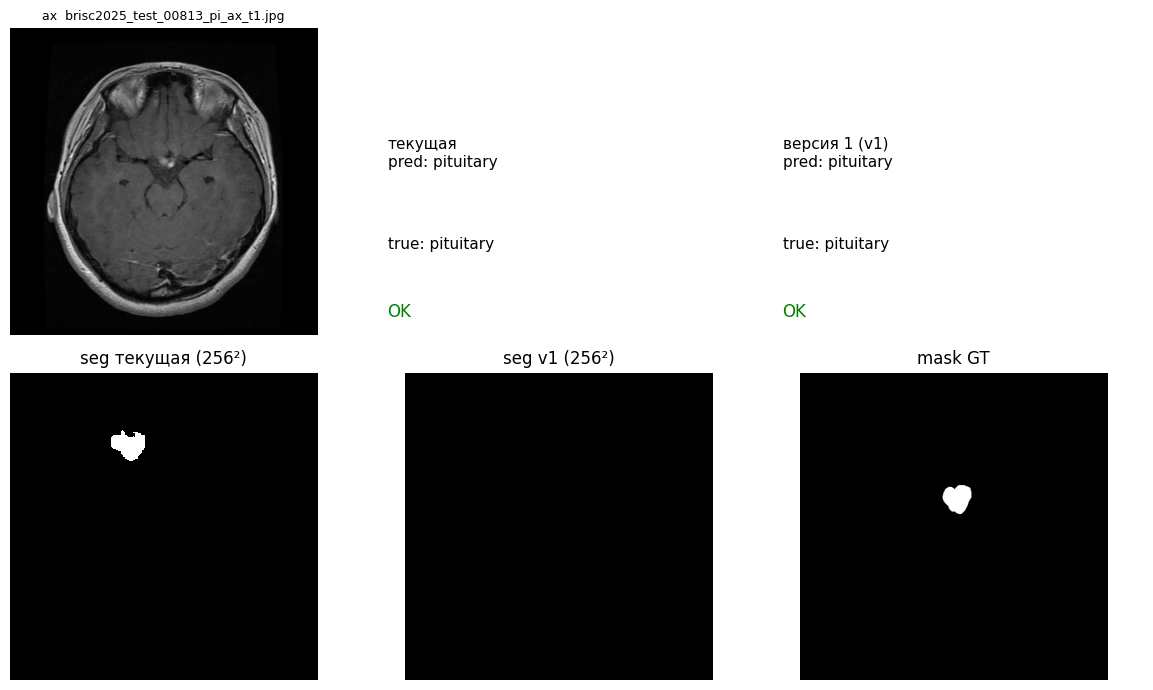

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


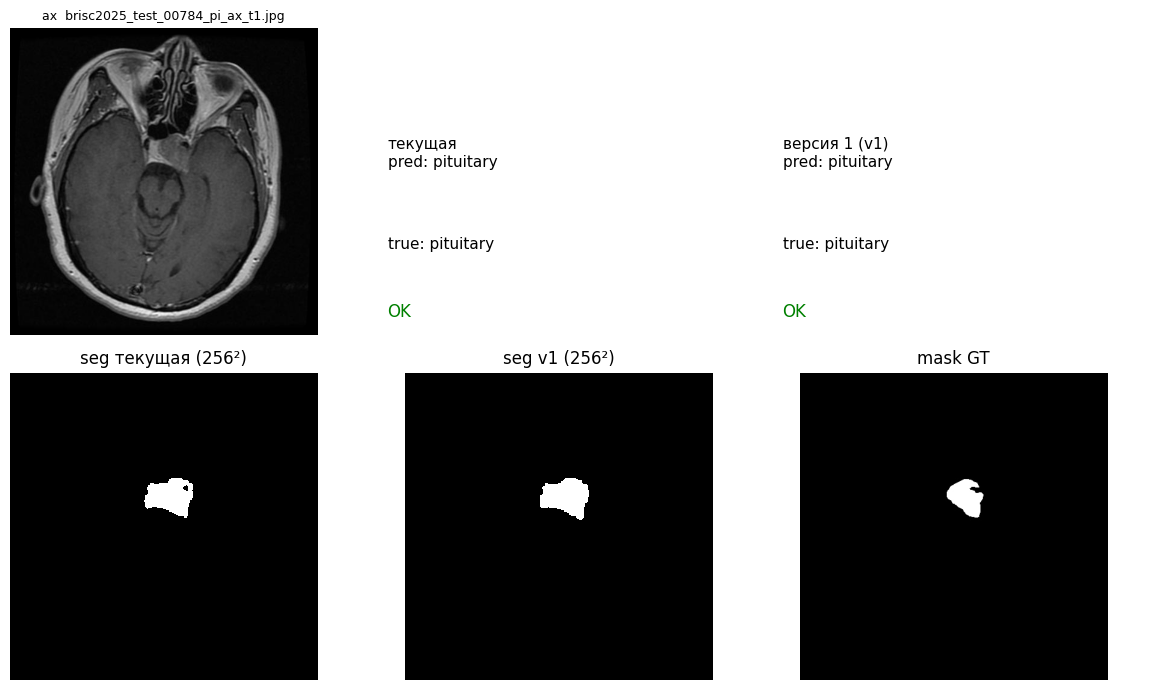

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


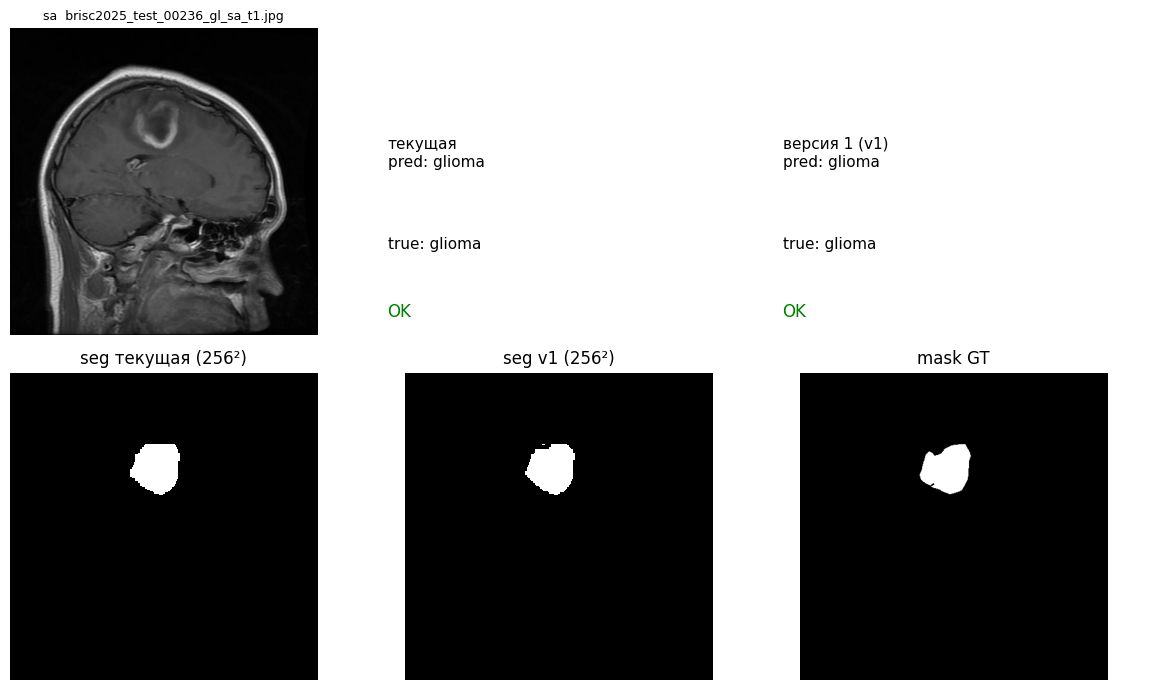

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


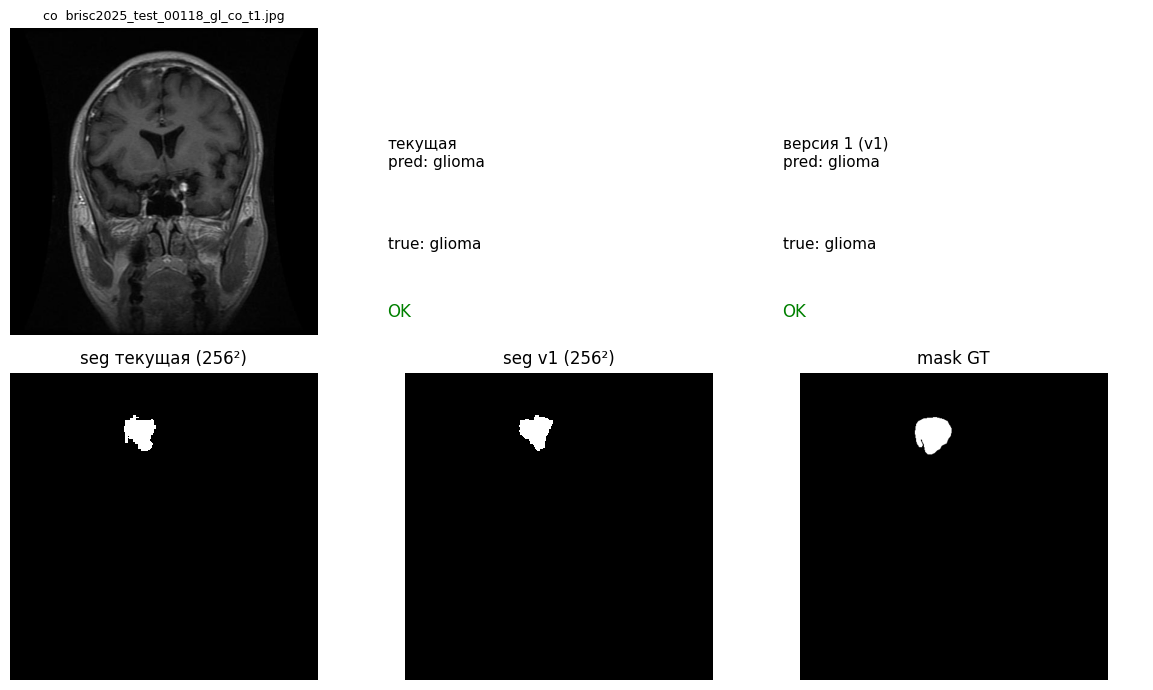

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


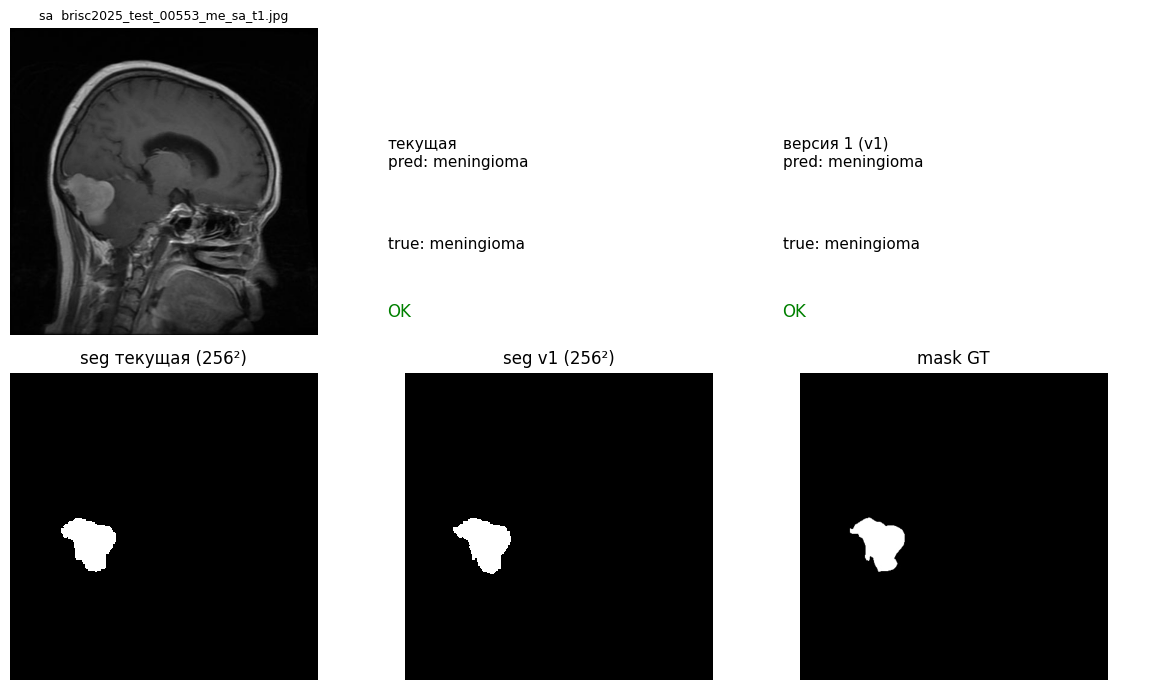

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


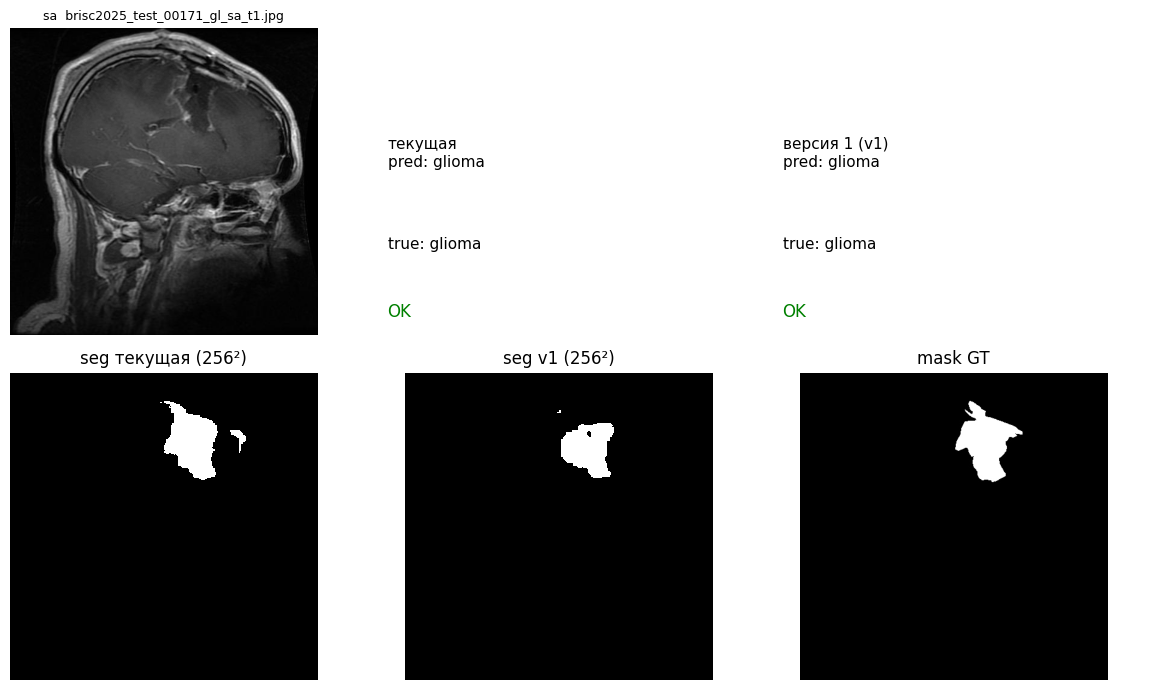

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


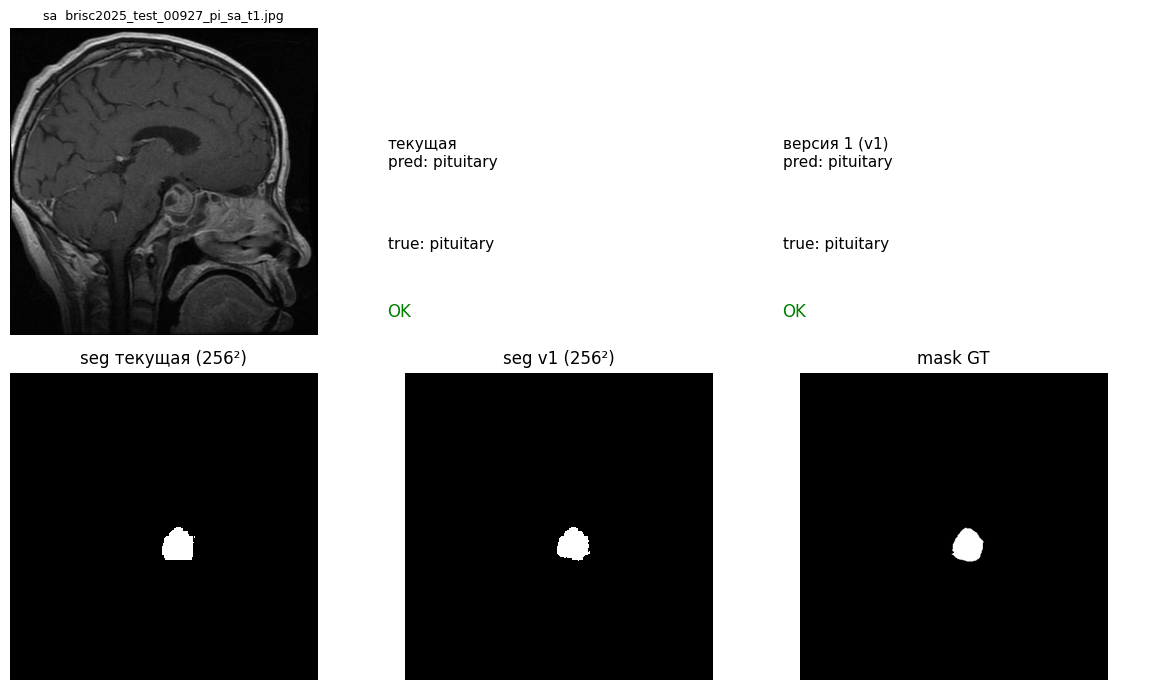

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


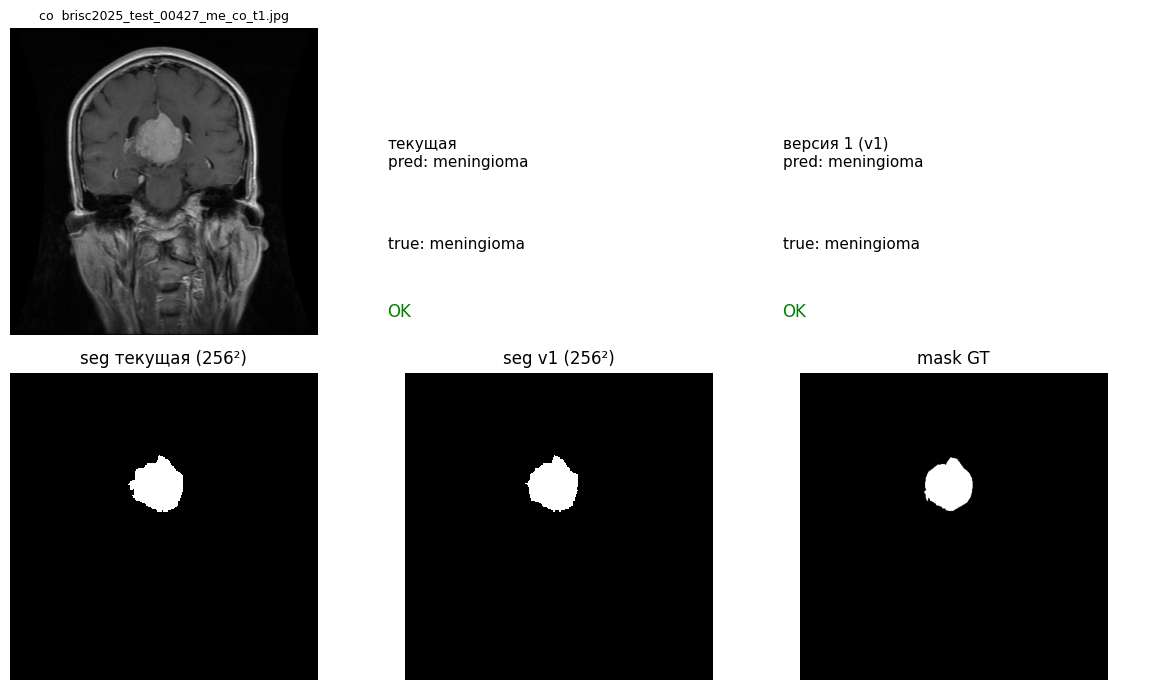

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


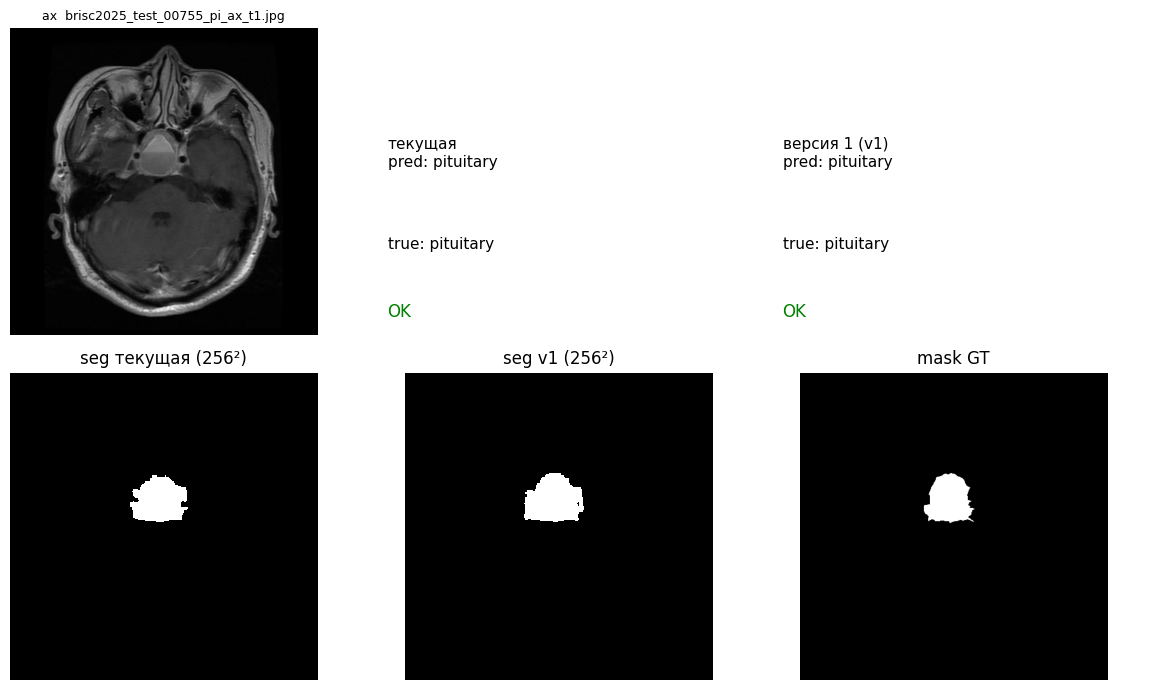

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


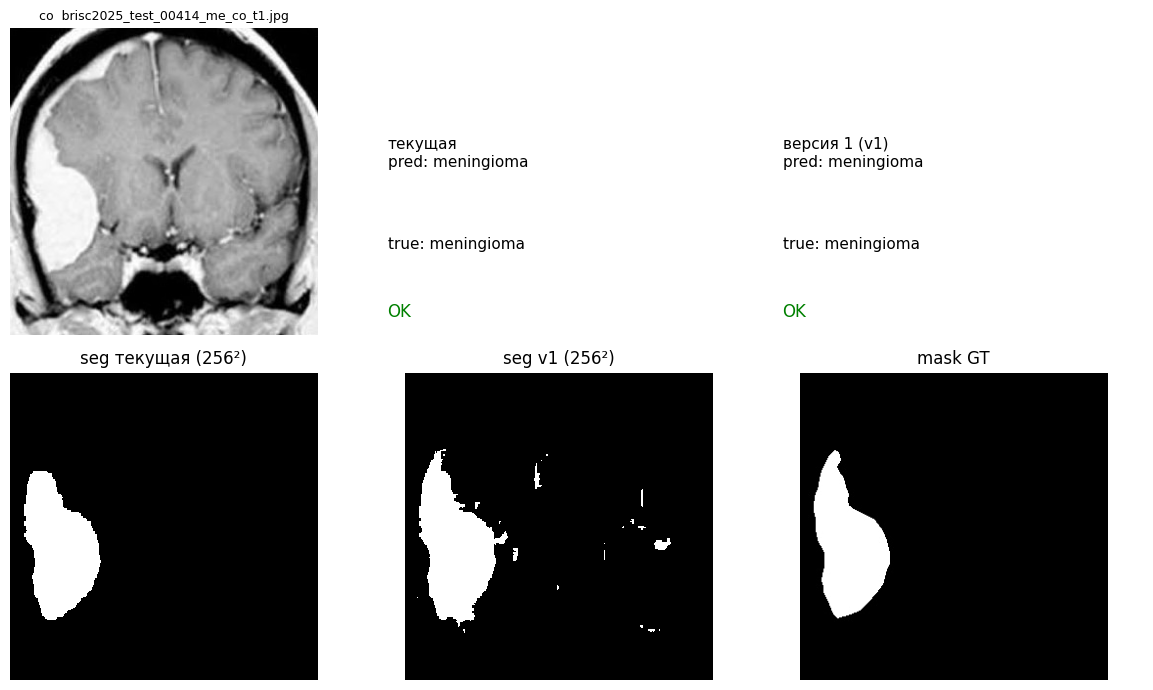

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


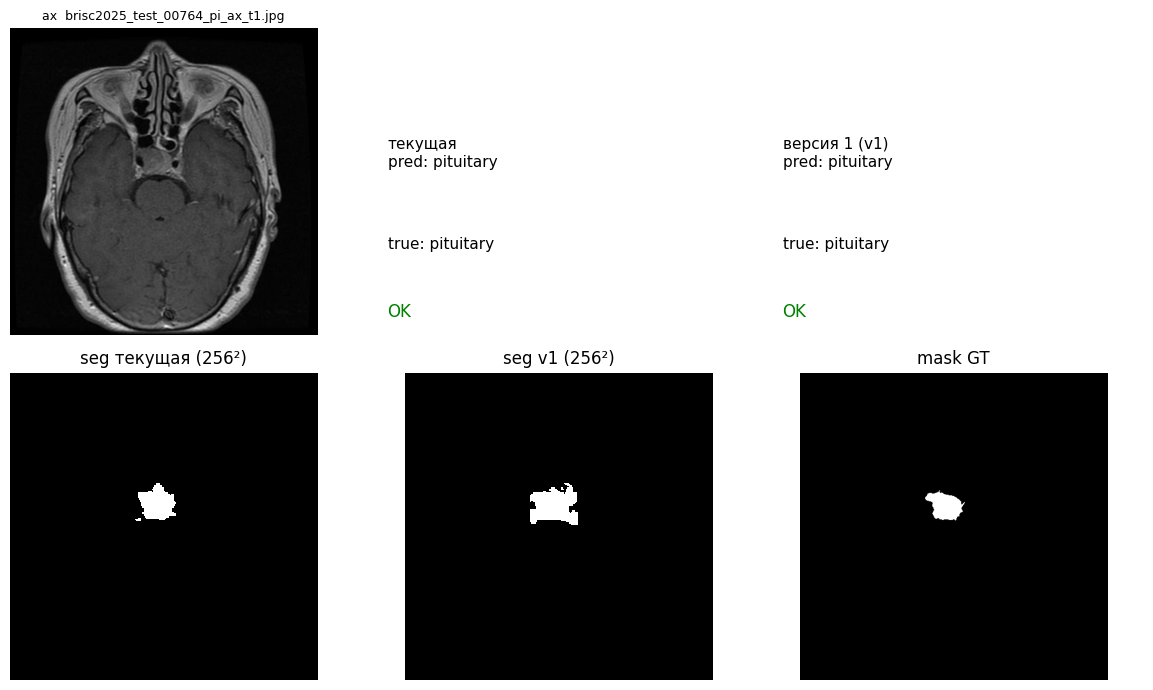

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


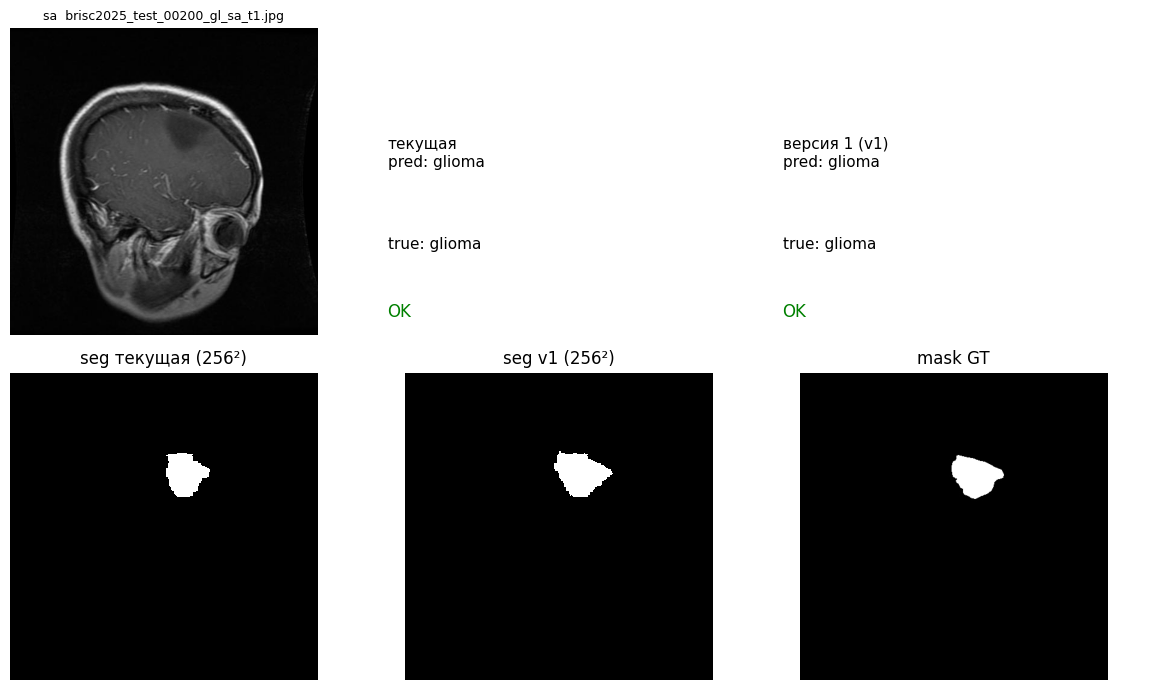

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


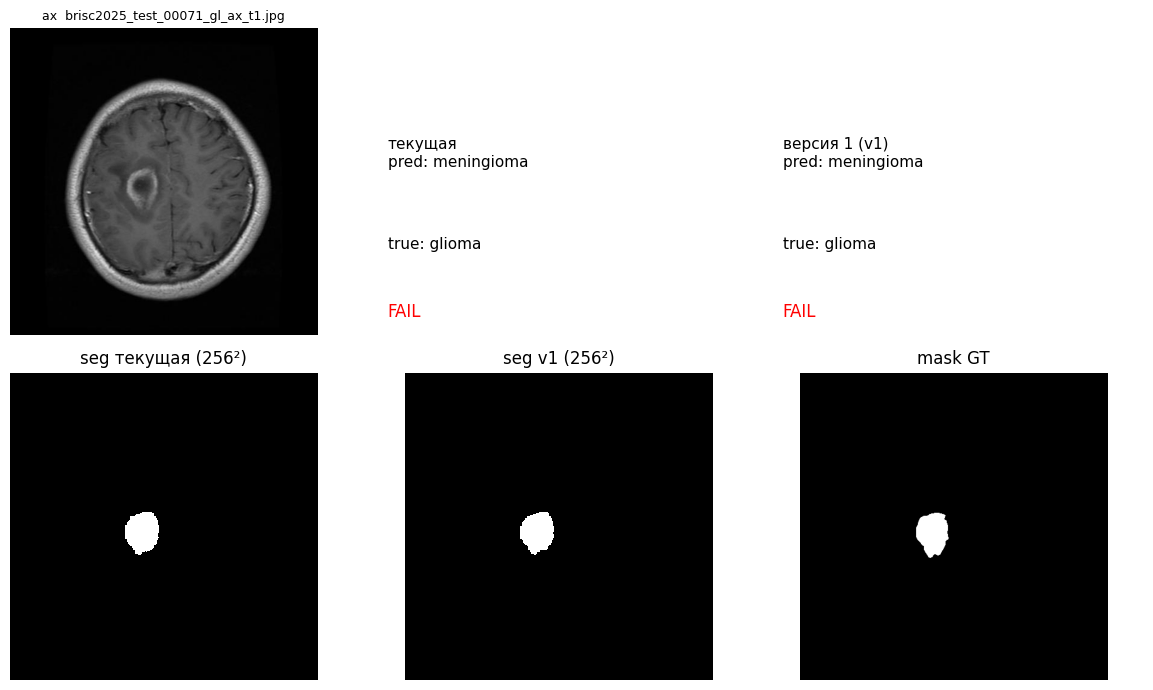

текущая: cls pred=meningioma  true=glioma  FAIL
v1:      cls pred=meningioma  true=glioma  FAIL


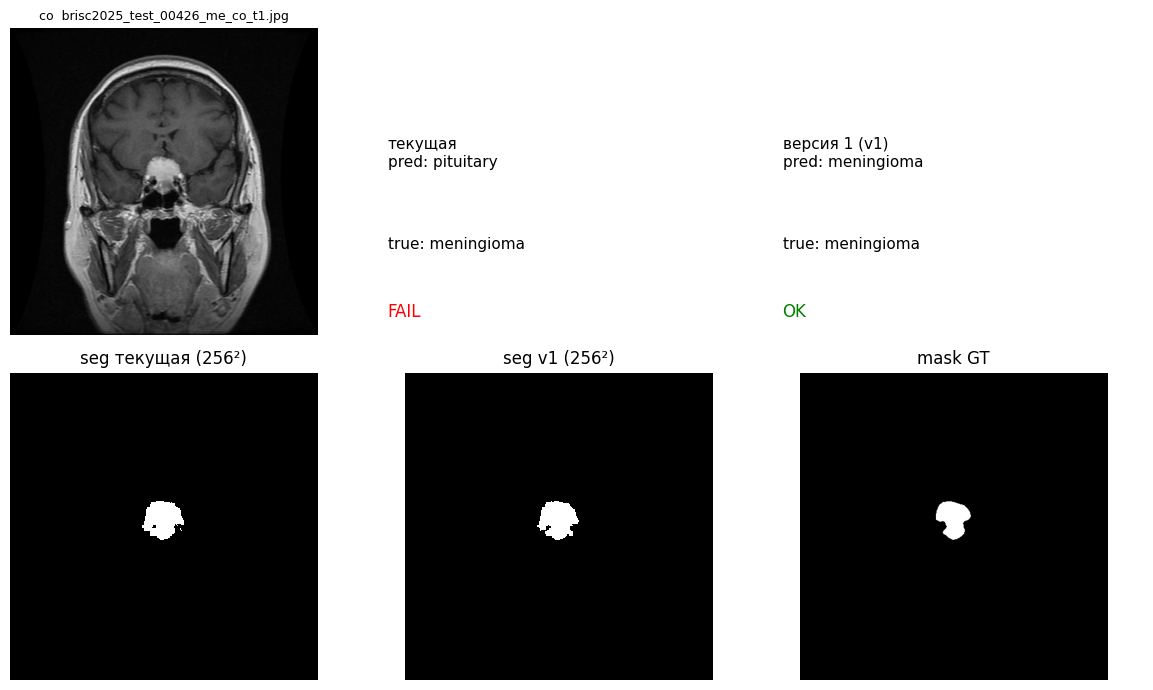

текущая: cls pred=pituitary  true=meningioma  FAIL
v1:      cls pred=meningioma  true=meningioma  OK


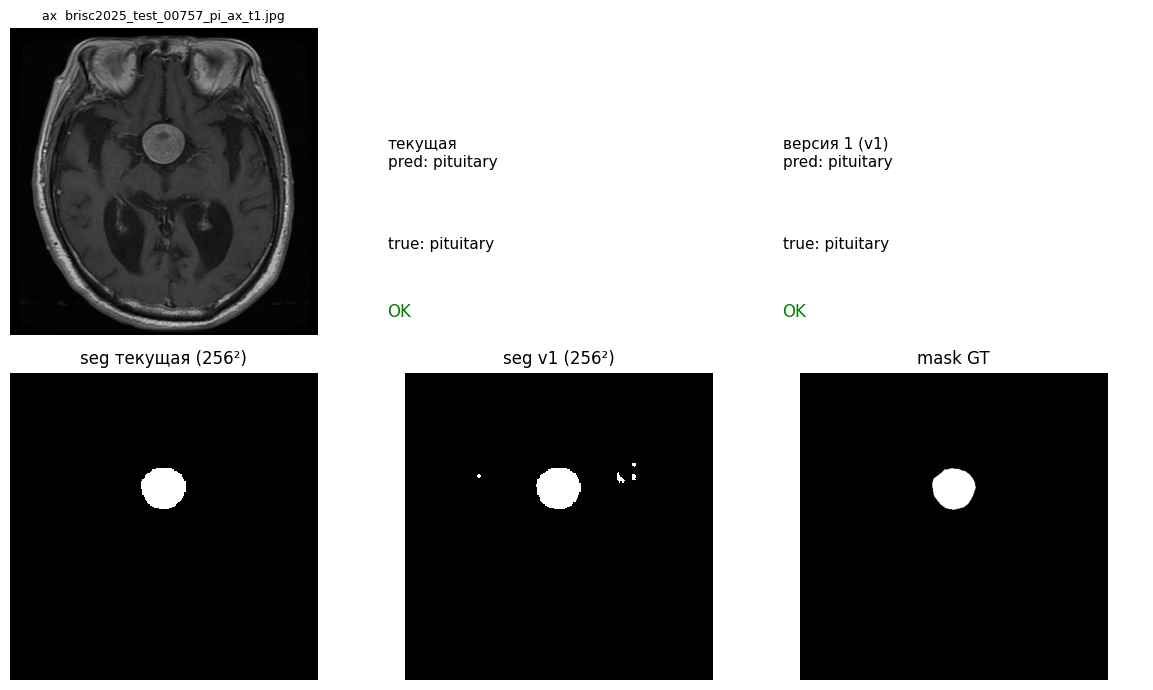

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


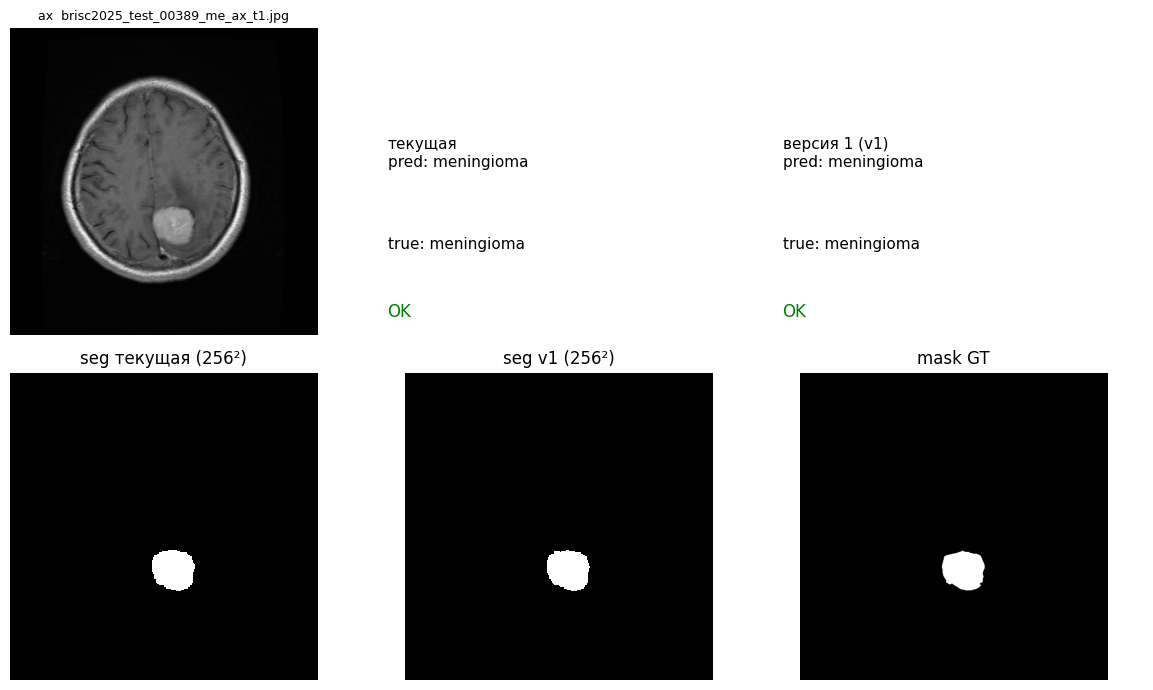

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


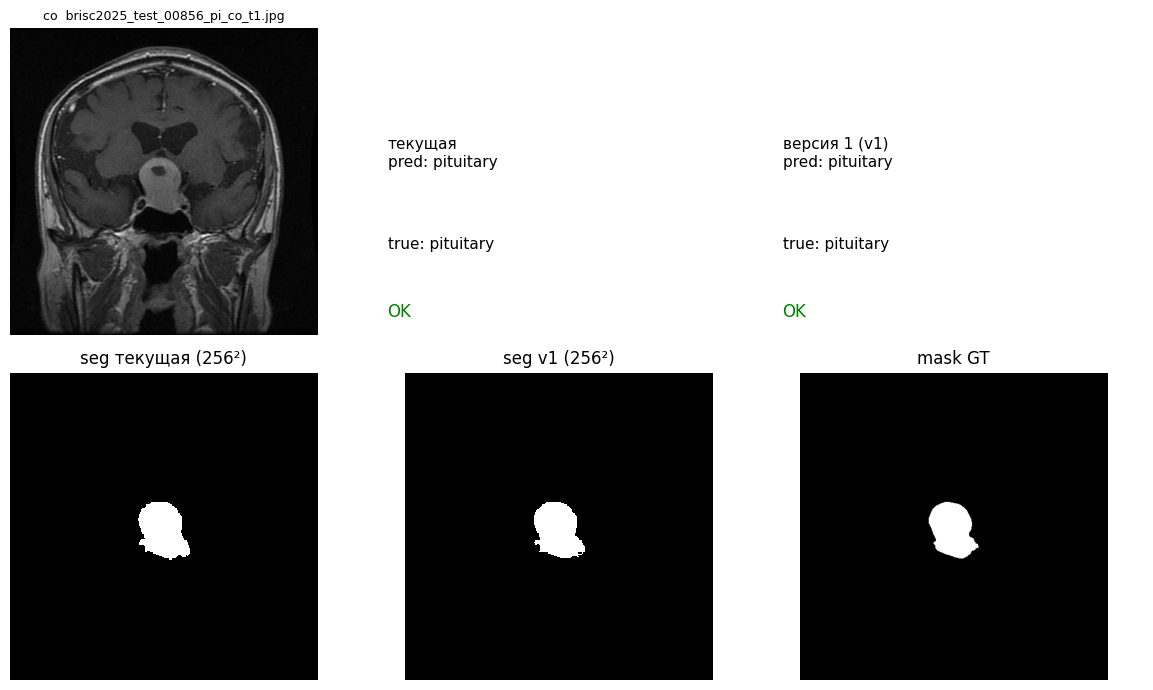

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


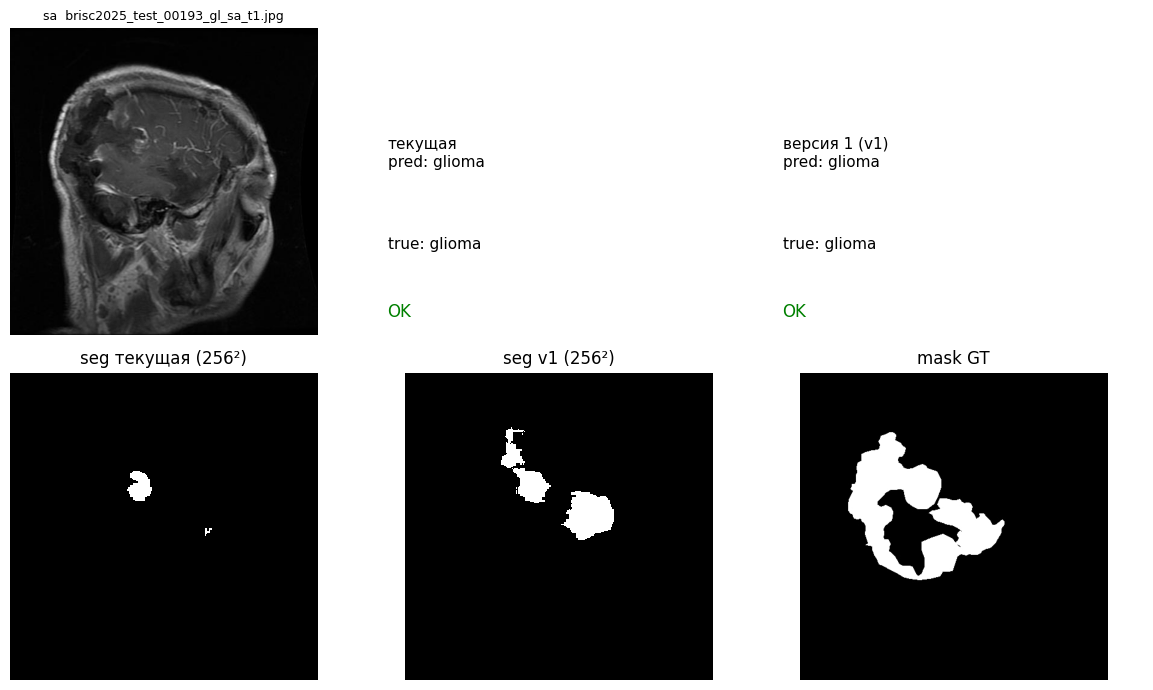

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


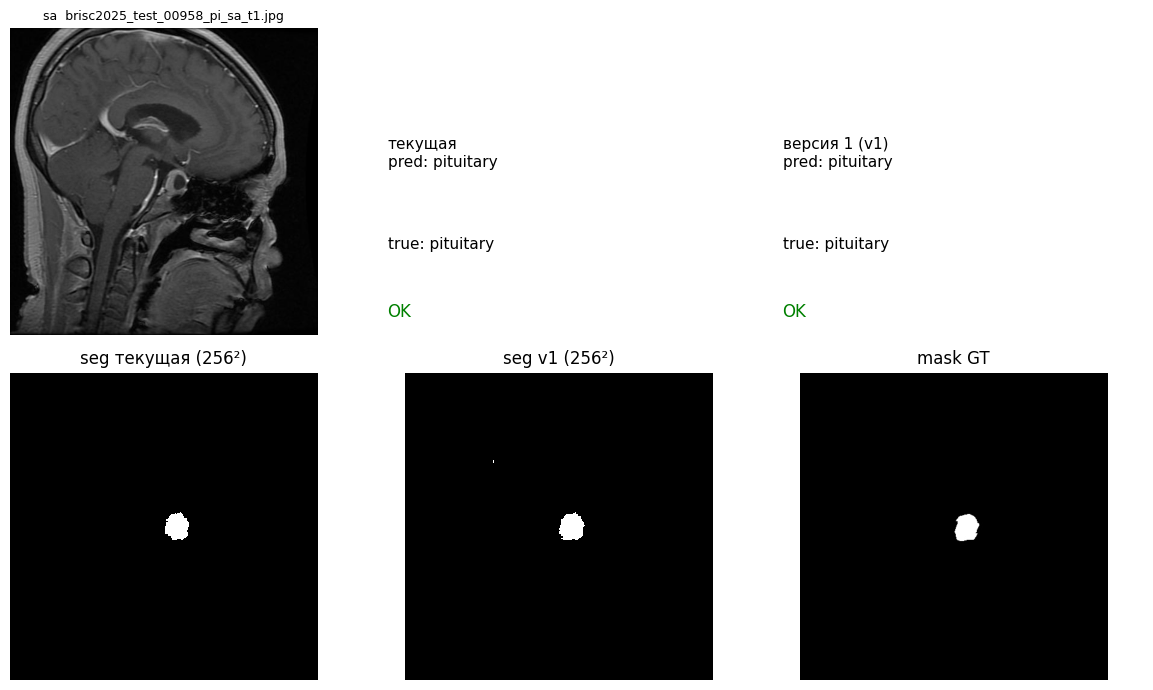

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


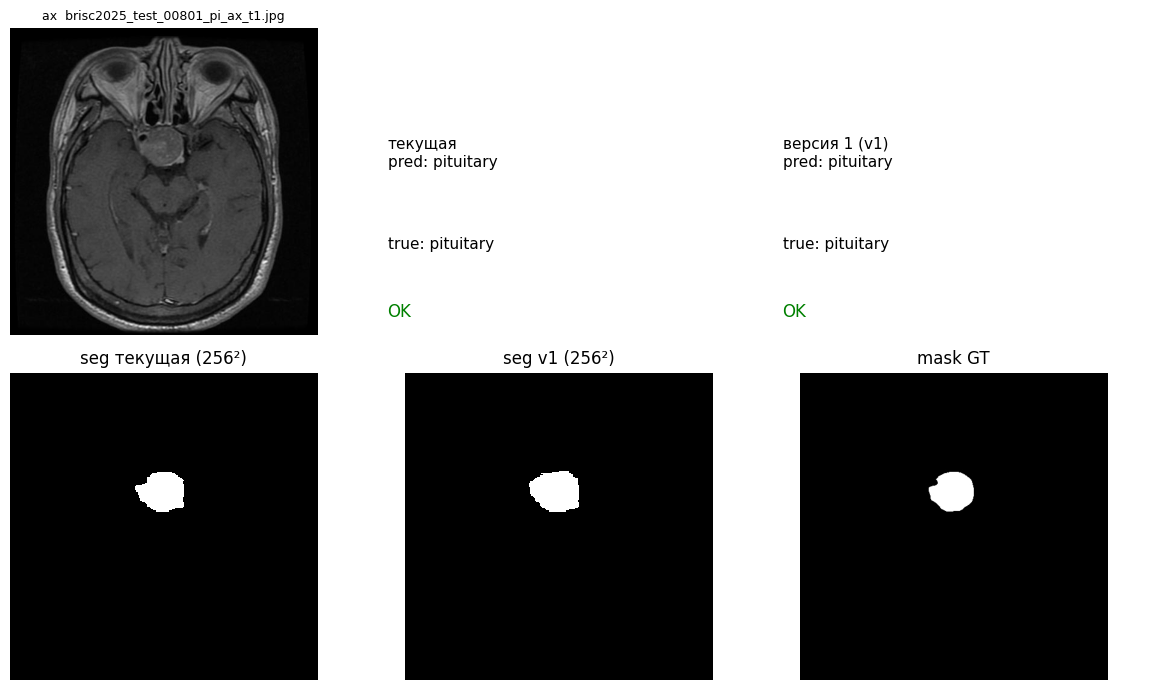

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


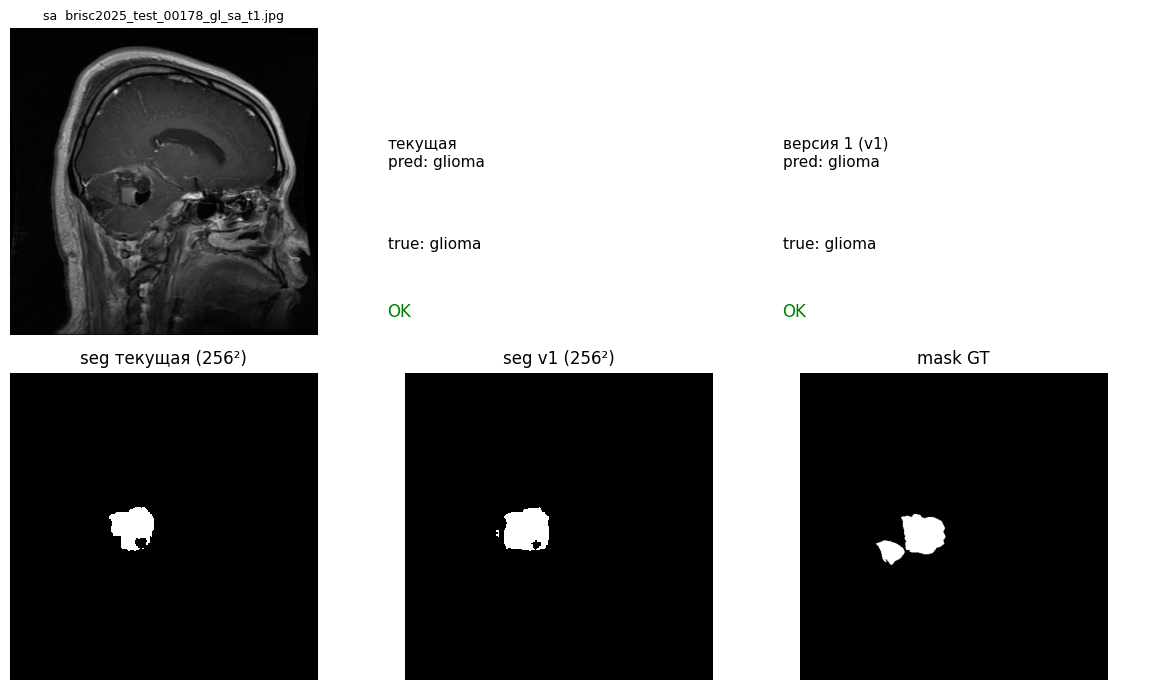

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


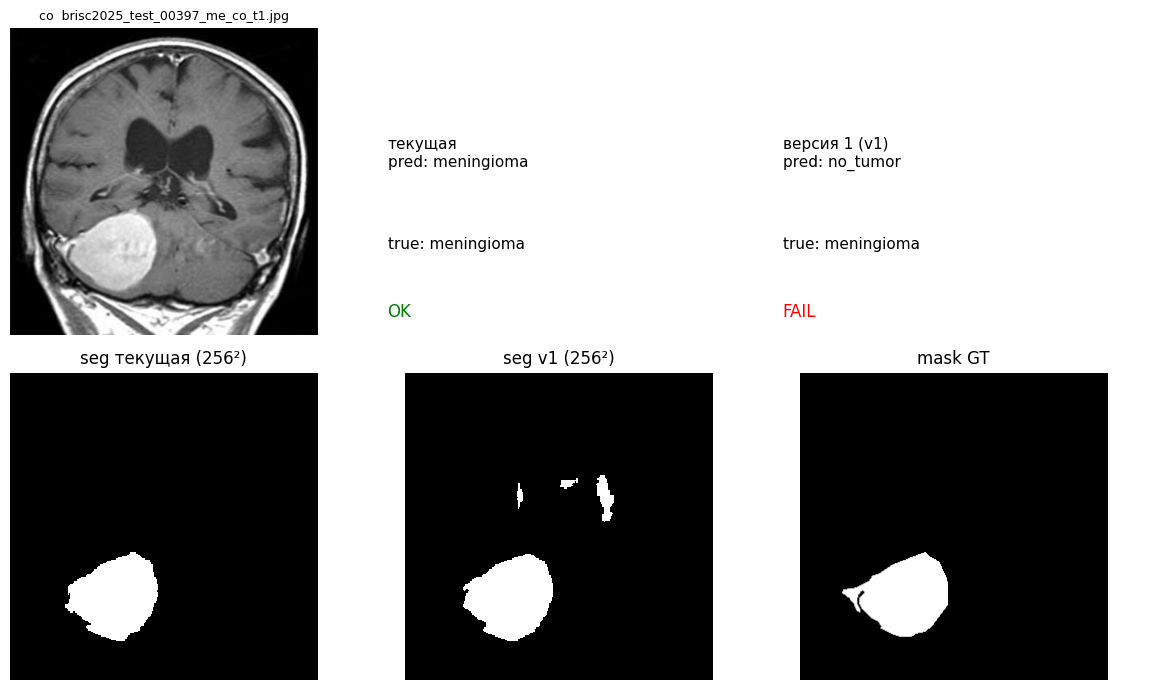

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=no_tumor  true=meningioma  FAIL


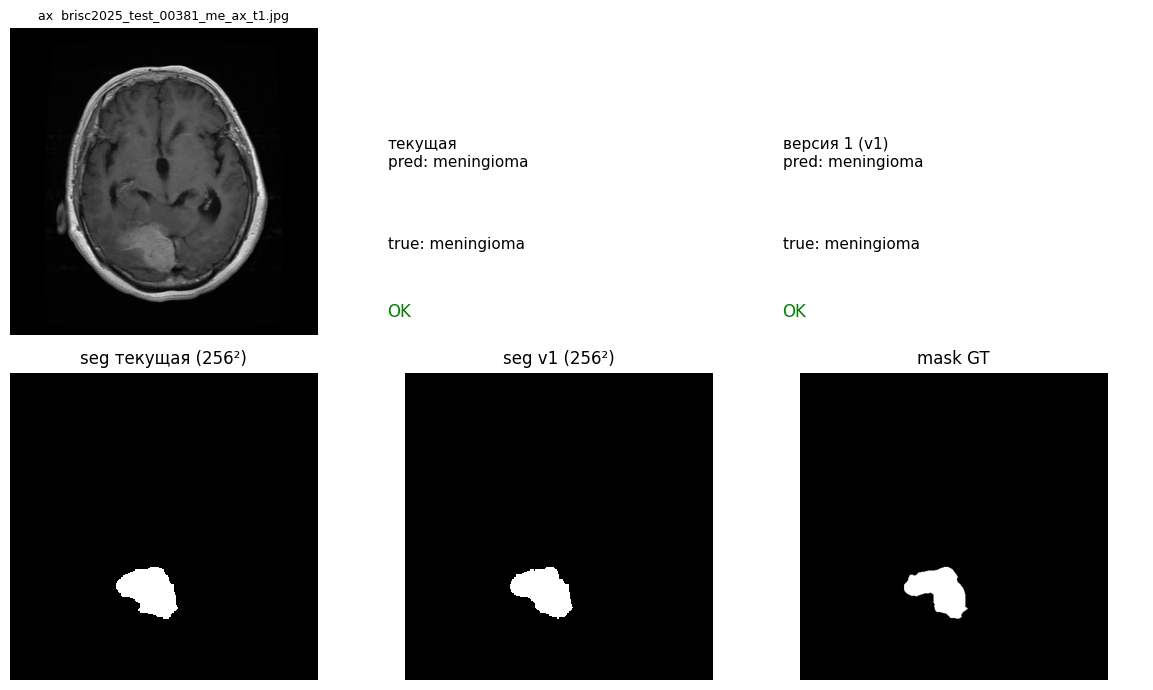

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


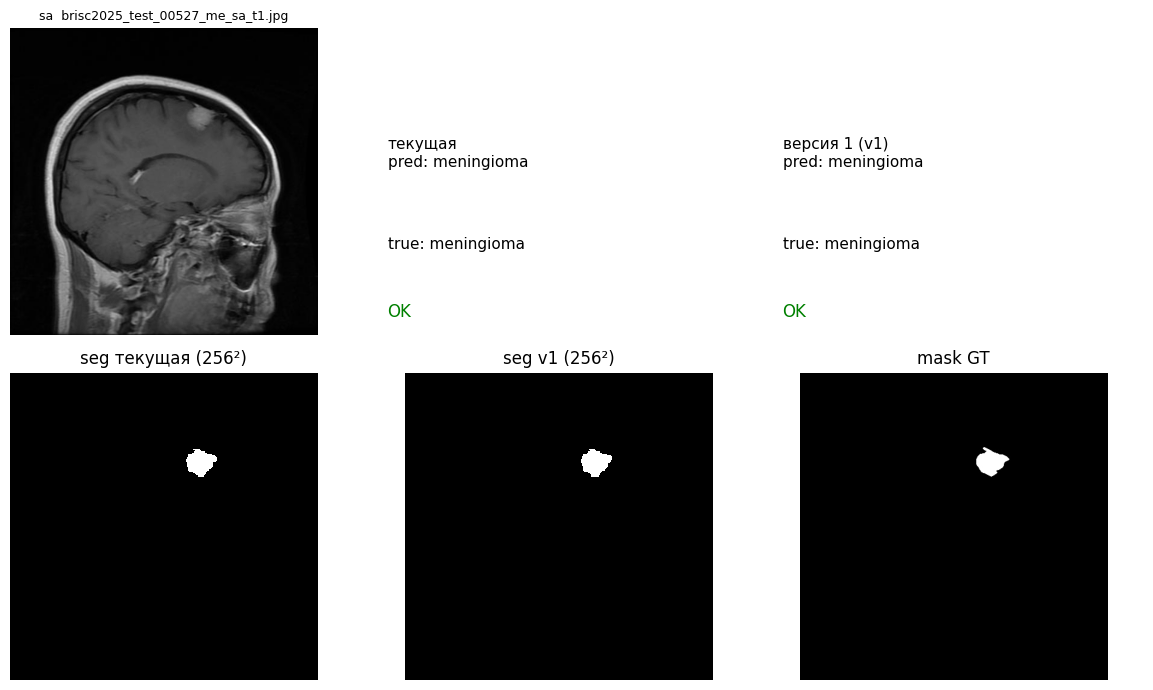

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


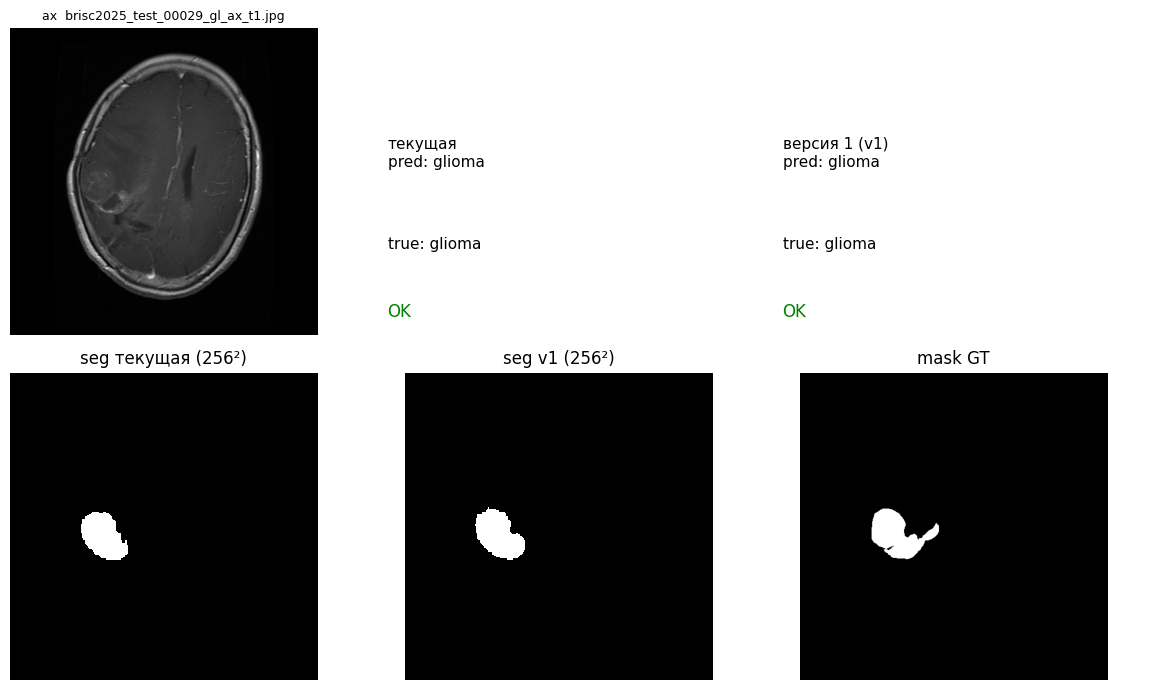

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


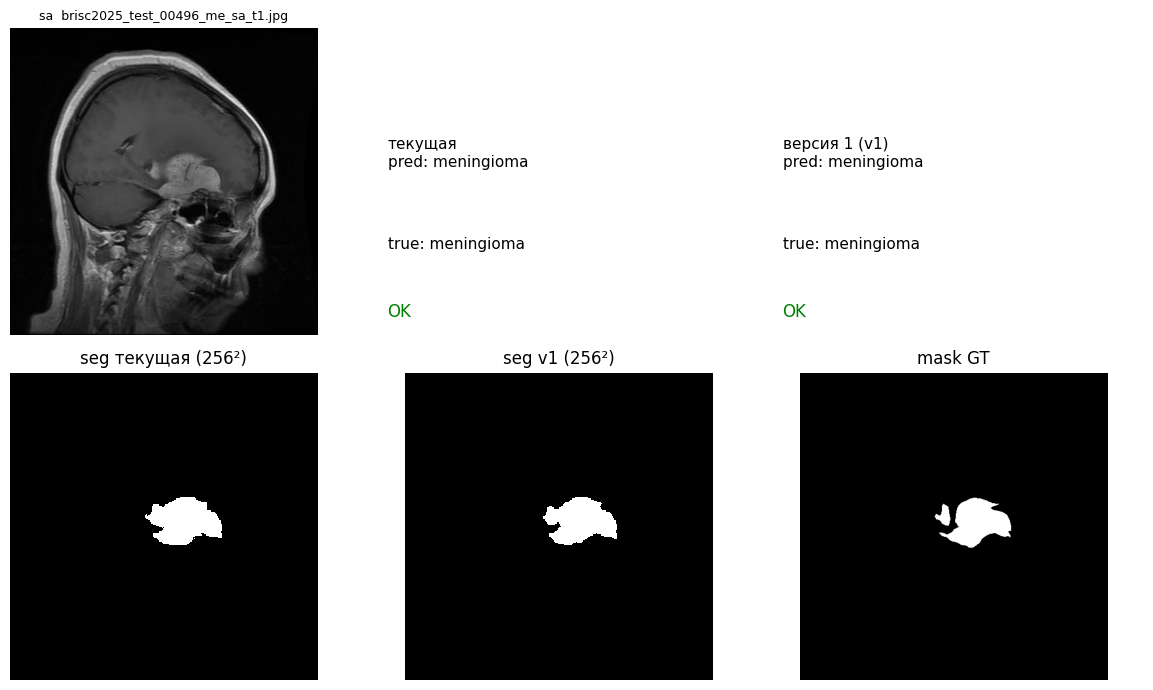

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


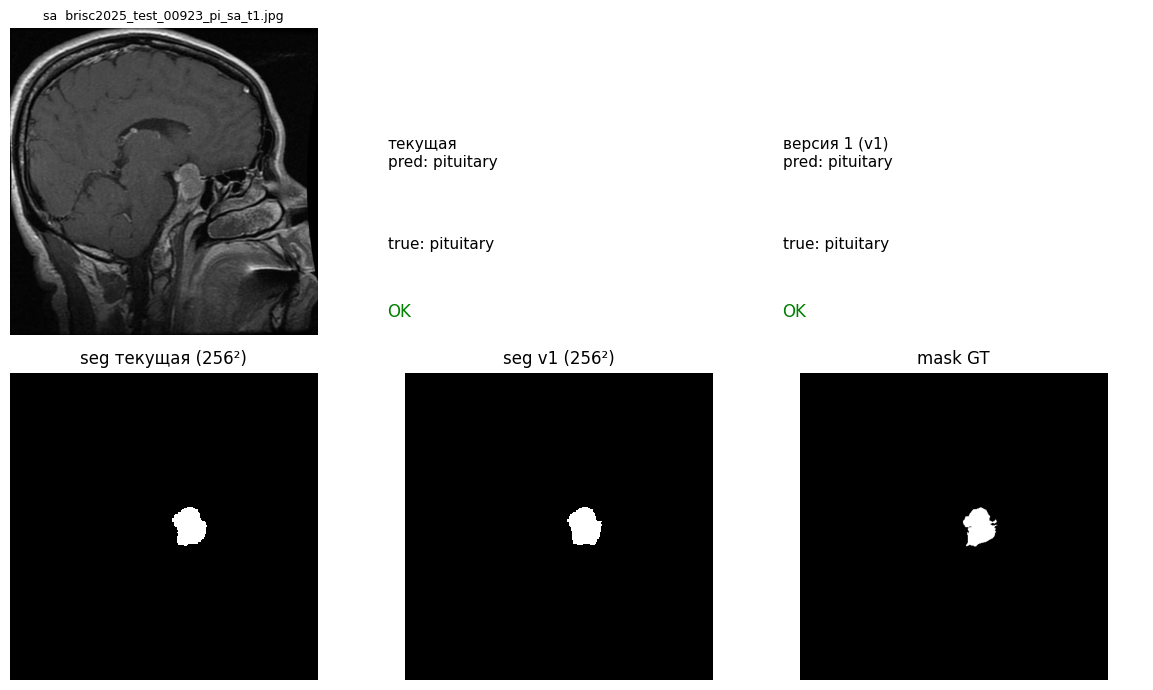

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


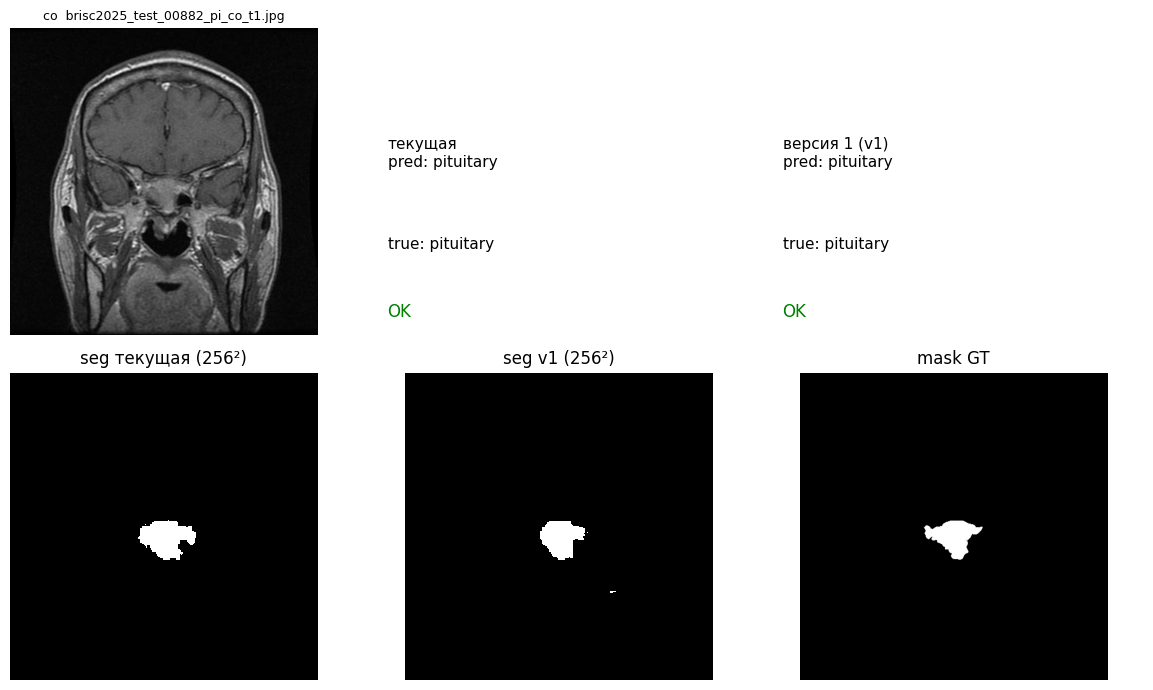

текущая: cls pred=pituitary  true=pituitary  OK
v1:      cls pred=pituitary  true=pituitary  OK


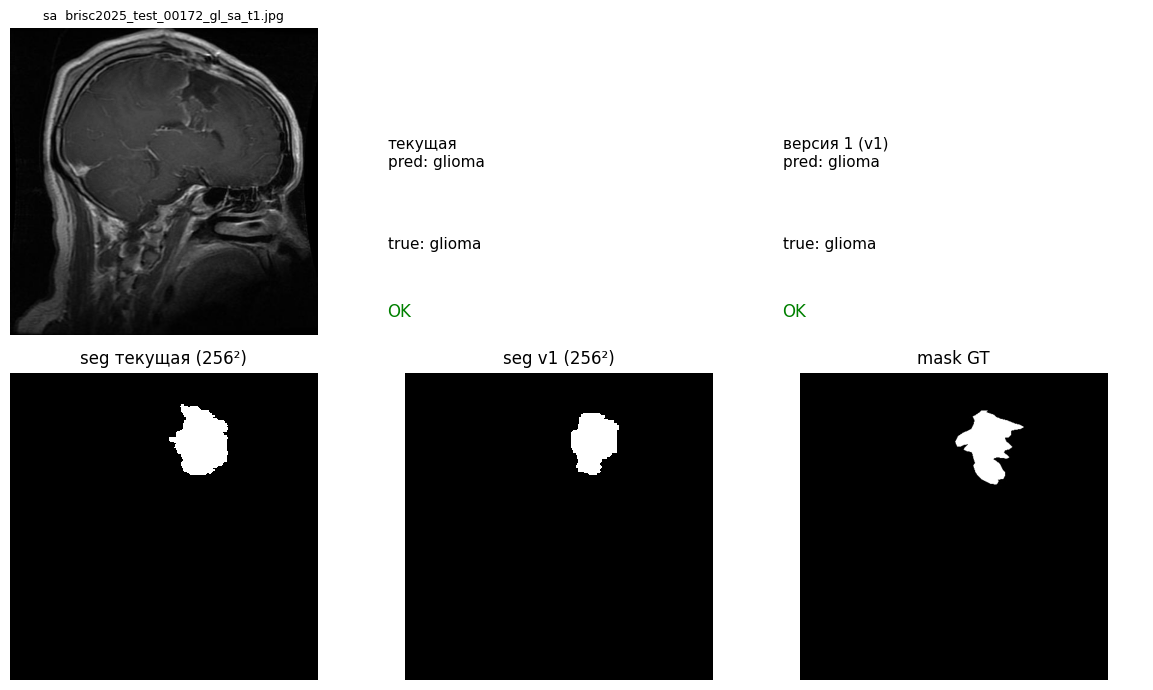

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


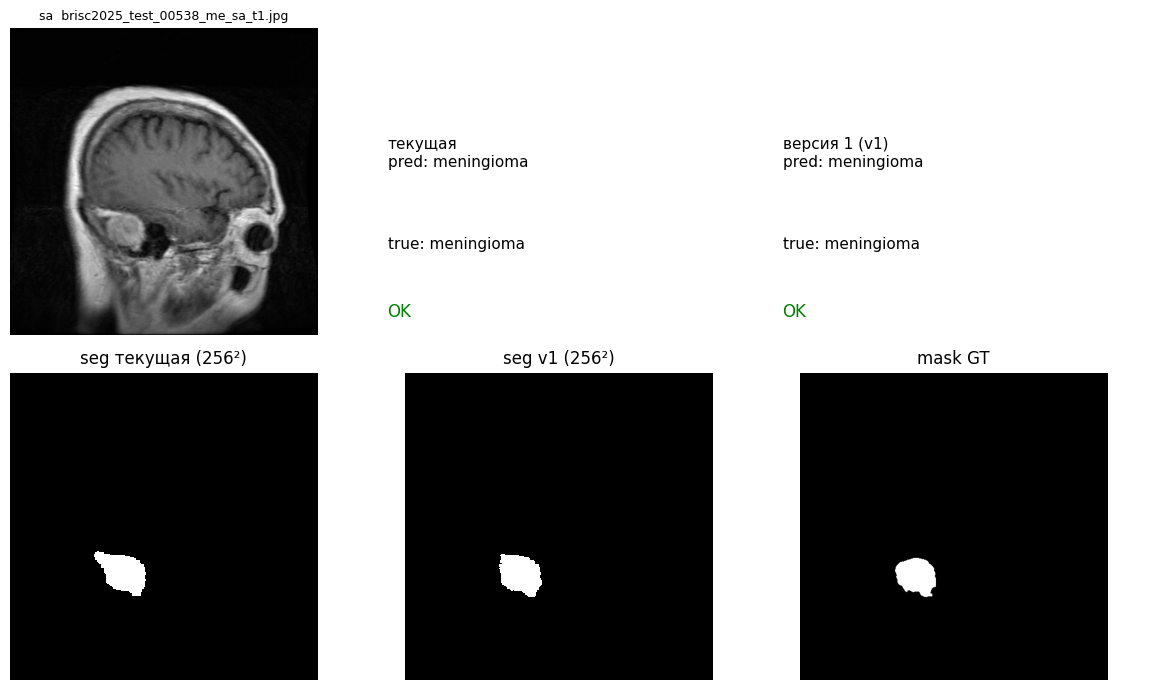

текущая: cls pred=meningioma  true=meningioma  OK
v1:      cls pred=meningioma  true=meningioma  OK


In [20]:
import random

N = 30

candidates: list[Path] = []
for pl in ("ax", "co", "sa"):
    img_dir = DATA_SEG / pl / "test" / "images"
    if not img_dir.is_dir():
        continue
    for p in img_dir.glob("*.jpg"):
        mask = p.parent.parent / "masks" / f"{p.stem}.png"
        if mask.is_file():
            candidates.append(p.resolve())

if not candidates:
    raise FileNotFoundError(f"Нет пар изображение+маска под {DATA_SEG.resolve()}")

k = min(N, len(candidates))
chosen = random.sample(candidates, k)
print(f"Выбрано {k} из {len(candidates)} тестовых снимков")

for path in chosen:
    plane = path.parent.parent.parent.name
    show_prediction_compare(path, plane)

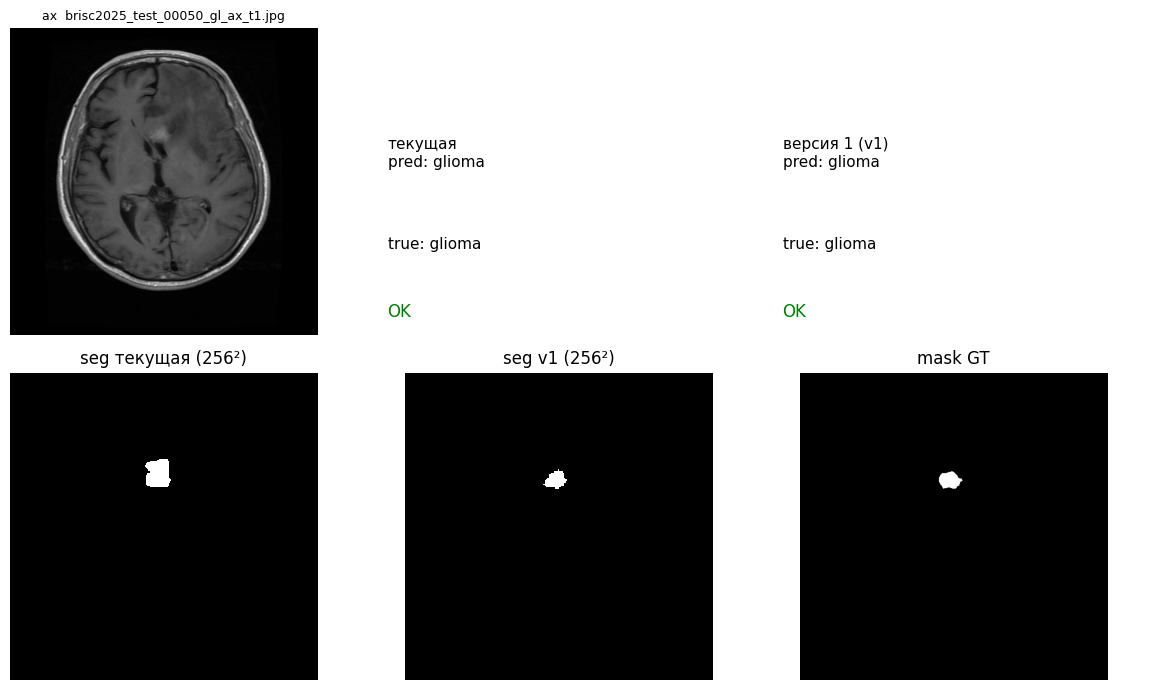

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=glioma  true=glioma  OK


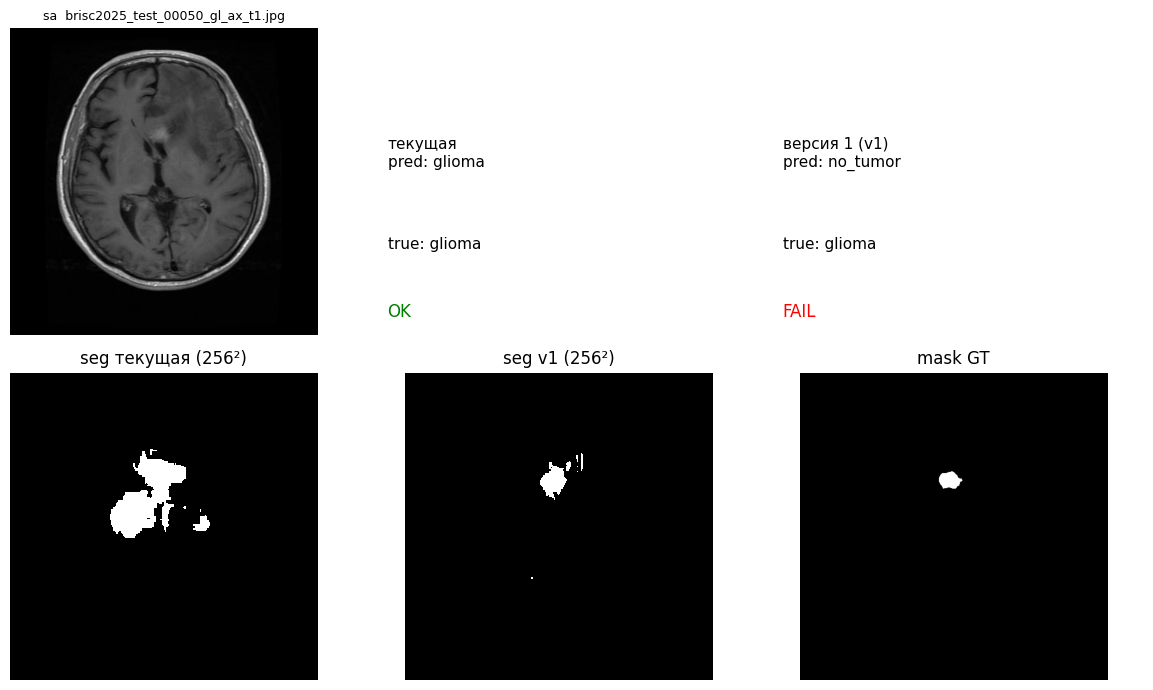

текущая: cls pred=glioma  true=glioma  OK
v1:      cls pred=no_tumor  true=glioma  FAIL


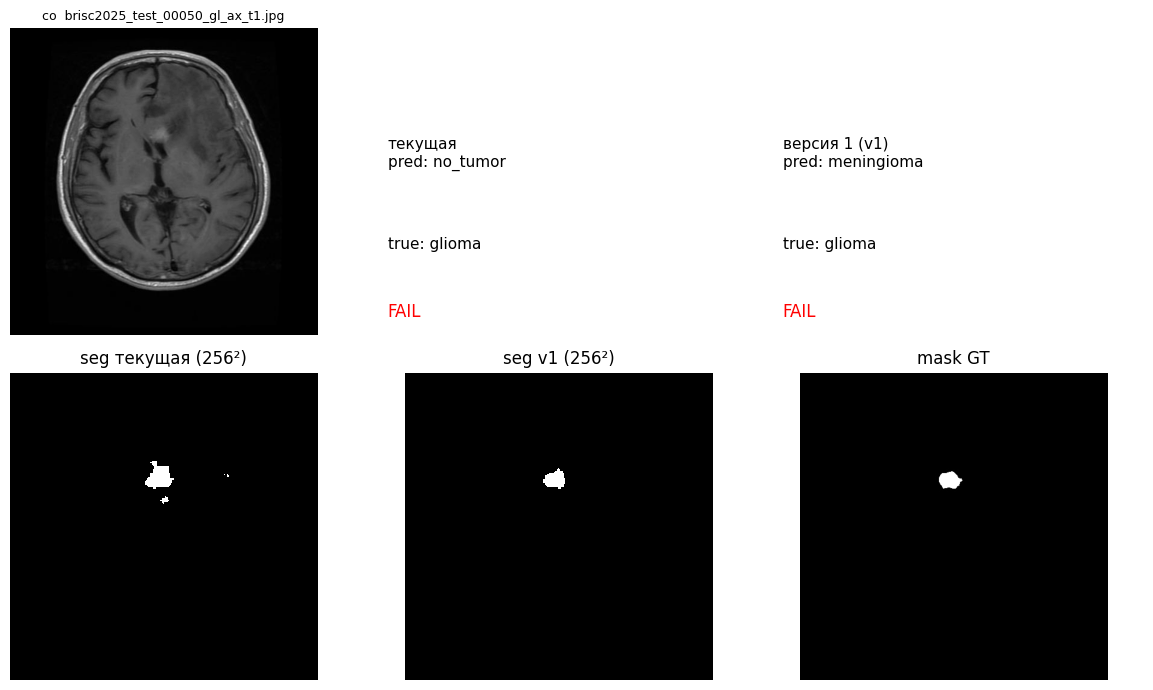

текущая: cls pred=no_tumor  true=glioma  FAIL
v1:      cls pred=meningioma  true=glioma  FAIL


In [21]:
# Один файл — обе версии; для плоскости снимка задайте plane. Для других плоскостей — другой plane.
_example = DATA_SEG / "ax" / "test" / "images" / "brisc2025_test_00050_gl_ax_t1.jpg"
if _example.is_file():
    show_prediction_compare(_example, "ax")
    show_prediction_compare(_example, "sa")
    show_prediction_compare(_example, "co")
else:
    print("Подставьте существующий путь под _example")
